# DenseNet-201

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 230

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
DATA_DIR = "../data"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

assert os.path.exists(IMAGENETTE_PATH), f"Imagenette not found at {IMAGENETTE_PATH}"
print("Imagenette found, reusing existing download.")

Imagenette found, reusing existing download.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [4]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate, bn_size=4):
        super().__init__()
        inter_channels = bn_size * growth_rate

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, inter_channels, kernel_size=1, bias=False)

        self.bn2 = nn.BatchNorm2d(inter_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(inter_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv1(self.relu1(self.bn1(x)))
        out = self.conv2(self.relu2(self.bn2(out)))
        return torch.cat([x, out], dim=1)

In [5]:
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate, bn_size=4):
        super().__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate, bn_size))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [6]:
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(self.relu(self.bn(x)))
        return self.pool(x)

In [7]:
class DenseNet201(nn.Module):
    
    block_config = [6, 12, 48, 32]
    growth_rate = 32
    bn_size = 4
    compression = 0.5

    def __init__(self, num_classes=10):
        super().__init__()
        num_init_features = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, num_init_features, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(num_init_features),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        num_features = num_init_features
        blocks = []
        for i, num_layers in enumerate(self.block_config):
            blocks.append(DenseBlock(num_layers, num_features, self.growth_rate, self.bn_size))
            num_features += num_layers * self.growth_rate

            if i != len(self.block_config) - 1:
                out_features = int(num_features * self.compression)
                blocks.append(TransitionLayer(num_features, out_features))
                num_features = out_features

        self.dense_blocks = nn.Sequential(*blocks)

        self.final_bn = nn.BatchNorm2d(num_features)
        self.final_relu = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(num_features, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.dense_blocks(x)
        x = self.final_relu(self.final_bn(x))
        x = self.avgpool(x)
        x = x.flatten(1)
        return self.fc(x)

model = DenseNet201(num_classes=10).to(device)
print(model)

DenseNet201(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (dense_blocks): Sequential(
    (0): DenseBlock(
      (block): Sequential(
        (0): DenseLayer(
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (1): DenseLayer(
          (bn1): BatchNorm2d(96, eps=1e-05, momentum

In [8]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [64, 10]

Output shape: torch.Size([64, 10])


In [9]:
def count_conv_params(in_ch, out_ch, kernel_size):
    return kernel_size * kernel_size * in_ch * out_ch

def count_bn_params(num_features):
    return 2 * num_features

densenet169_layers = sum([6, 12, 32, 32])
densenet201_layers = sum(model.block_config)
print(f"DenseNet-169 DenseLayers: {densenet169_layers}")
print(f"DenseNet-201 DenseLayers: {densenet201_layers}")
print(f"Extra layers, entirely in block 3: {densenet201_layers - densenet169_layers}")

in_ch = 64 + 2 * 32
inter_ch = 4 * 32

bn1 = count_bn_params(in_ch)
conv1 = count_conv_params(in_ch, inter_ch, 1)
bn2 = count_bn_params(inter_ch)
conv2 = count_conv_params(inter_ch, 32, 3)

layer_manual = bn1 + conv1 + bn2 + conv2
layer_torch = sum(p.numel() for p in model.dense_blocks[0].block[2].parameters())

print(f"\nDenseLayer manual total: {layer_manual:,}")
print(f"DenseLayer torch total:  {layer_torch:,}")
assert layer_manual == layer_torch, "Mismatch in DenseLayer parameter count"

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal DenseNet-201 parameters: {total_params:,}")

DenseNet-169 DenseLayers: 82
DenseNet-201 DenseLayers: 98
Extra layers, entirely in block 3: 16

DenseLayer manual total: 53,760
DenseLayer torch total:  53,760

Total DenseNet-201 parameters: 18,112,138


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [12]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=1.8285 train_acc=0.3744 | val_loss=1.4973 val_acc=0.5032 | time=229.5s
Epoch 2/10 | train_loss=1.4198 train_acc=0.5349 | val_loss=1.2062 val_acc=0.6089 | time=224.6s
Epoch 3/10 | train_loss=1.2414 train_acc=0.5914 | val_loss=1.0816 val_acc=0.6599 | time=223.7s
Epoch 4/10 | train_loss=1.1430 train_acc=0.6305 | val_loss=0.9763 val_acc=0.6879 | time=223.5s
Epoch 5/10 | train_loss=1.0633 train_acc=0.6572 | val_loss=0.9805 val_acc=0.6882 | time=223.6s
Epoch 6/10 | train_loss=0.9882 train_acc=0.6761 | val_loss=0.9192 val_acc=0.7019 | time=223.5s
Epoch 7/10 | train_loss=0.9647 train_acc=0.6896 | val_loss=0.9270 val_acc=0.7027 | time=224.0s
Epoch 8/10 | train_loss=0.9074 train_acc=0.7064 | val_loss=0.8772 val_acc=0.7225 | time=225.4s
Epoch 9/10 | train_loss=0.8715 train_acc=0.7141 | val_loss=0.7636 val_acc=0.7618 | time=223.9s
Epoch 10/10 | train_loss=0.8441 train_acc=0.7261 | val_loss=0.7393 val_acc=0.7587 | time=223.8s


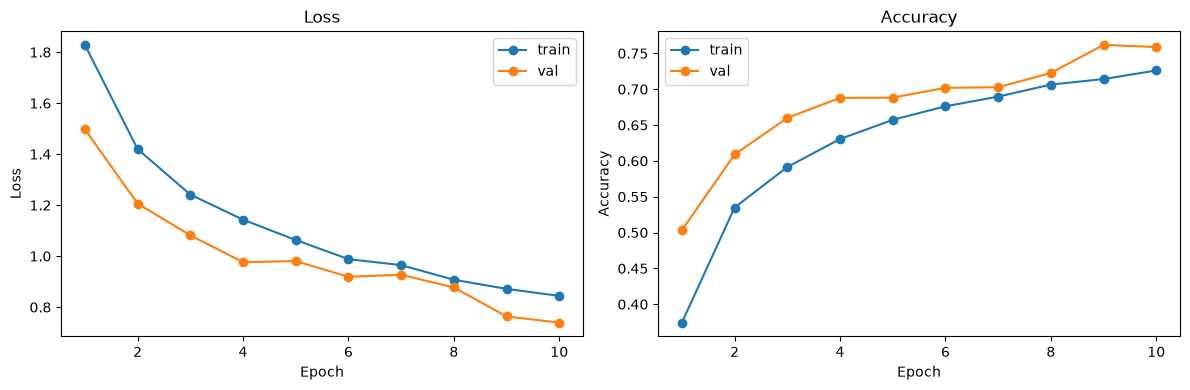

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

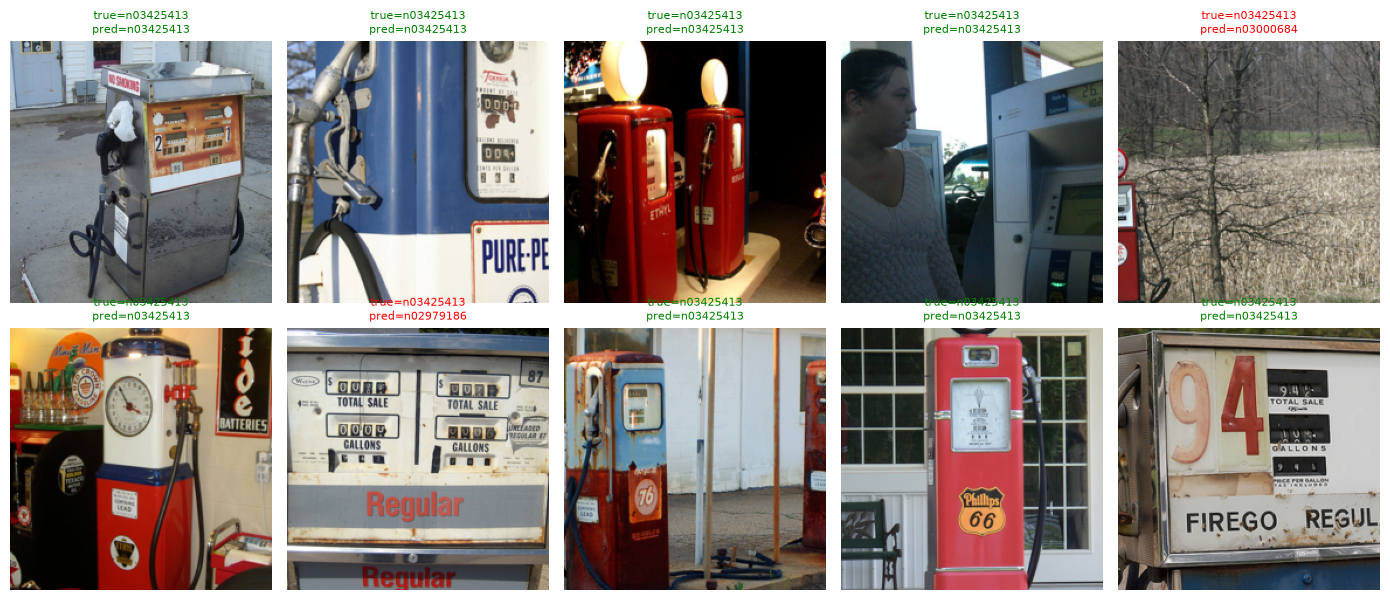

In [14]:
model.eval()

random_batch_idx = random.randint(0, len(val_loader) - 1)
for i, batch in enumerate(val_loader):
    if i == random_batch_idx:
        sample_images, sample_labels = batch
        break

class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: ~18M.
DenseNet-201 reuses the exact same DenseLayer/DenseBlock/TransitionLayer
building blocks as DenseNet-121/169; the extra depth over DenseNet-169
comes entirely from deepening block 3 (48 layers instead of 32), while
blocks 1, 2, and 4 are unchanged.

**Why Adam instead of SGD with momentum.** The original paper used SGD with
momentum=0.9, weight decay 0.0001, and a step learning rate schedule. We
used Adam for simpler, more reliable convergence without manual tuning.